In [1]:
import os
import datetime
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import mean_absolute_error
from importlib import reload

from utils import visualization, io_results, data, constants, client
from utils.voting import VotingProbabilities, VotingPick
from SoD.data_processing_utils import get_actual_results

In [2]:
actual_results_df = io_results.load_actual_results()
actual_results_country = actual_results_df[actual_results_df["region"]==constants.COUNTRY].iloc[0]

In [76]:
# Load voting results from saved files
# Modify the model name and file path as needed

CLIENT = client.OpenAIClient()
# CLIENT = client.GeminiClient()
# CLIENT = client.AnthropicClient()
# CLIENT = client.OpenRouterClient()

# MODEL = constants.GPT_41_NANO
MODEL = constants.GPT_4o_MINI
# MODEL = constants.GPT_41
# MODEL = constants.GPT_4o
# MODEL = constants.GEMINI_3_FLASH
# MODEL = constants.CLAUDE_SONNET_45

TEMPERATURE = 0

VOTING_RESULT = VotingProbabilities
# VOTING_RESULT = VotingPick

PARTY_COLUMNS = constants.PARTY_COLUMNS_2021
N = 3880

description = io_results.create_parameter_description(CLIENT,MODEL,VOTING_RESULT,N,TEMPERATURE)
voting_results = pd.read_csv(f"results/normalized_voting_results_{description}.csv")
party_results_df = voting_results[PARTY_COLUMNS]

claimed_results_df = pd.read_csv("data/clean_data.csv", index_col=0)
GET_RESULTS = get_actual_results

### Basic Statistics

In [71]:
voting_results.describe()

,Unnamed: 0.1,Unnamed: 0,Voted,Not Voted,ANO 2011,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",Koalice PIRÁTI a STAROSTOVÉ,Komunistická strana Čech a Moravy (KSČM),Svoboda a přímá demokracie – Tomio Okamura (SPD),Česká strana sociálně demokratická (ČSSD),"Trikolóra, Svobodní a Soukromníci",Přísaha Roberta Šlachty,Jiná strana
count,3880.00000,3880.00000,3880.000000,3880.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,1939.50000,1939.50000,0.734936,0.265064,0.240555,0.235429,0.136347,0.073353,0.112066,0.069012,0.042358,0.040415,0.050464
std,1120.20385,1120.20385,0.298912,0.298912,0.073729,0.087541,0.058811,0.049837,0.044342,0.044027,0.026503,0.034116,0.052276
min,0.00000,0.00000,0.000000,0.000000,0.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,969.75000,969.75000,0.700000,0.100000,0.200000,0.195122,0.100000,0.050000,0.100000,0.050000,0.024390,0.010526,0.010101
50%,1939.50000,1939.50000,0.850000,0.150000,0.250000,0.210526,0.125000,0.076923,0.100000,0.050000,0.050000,0.050000,0.050000
75%,2909.25000,2909.25000,0.900000,0.300000,0.294118,0.300000,0.195122,0.100000,0.111111,0.100000,0.052632,0.052632,0.062500
max,3879.00000,3879.00000,1.000000,1.000000,0.421053,0.600000,0.400000,0.333333,0.315789,0.400000,0.125000,0.300000,0.444444


In [72]:
voting_results

,Unnamed: 0.1,Unnamed: 0,Voted,Not Voted,ANO 2011,"Koalice Spolu (ODS, TOP 09, KDU-ČSL)",Koalice PIRÁTI a STAROSTOVÉ,Komunistická strana Čech a Moravy (KSČM),Svoboda a přímá demokracie – Tomio Okamura (SPD),Česká strana sociálně demokratická (ČSSD),"Trikolóra, Svobodní a Soukromníci",Přísaha Roberta Šlachty,Jiná strana,Prompt
0,0,0,1.0,0.0,0.200000,0.300000,0.250000,0.050000,0.100000,0.020000,0.020000,0.010000,0.050000,"Jsem muž, je mi 28 let, mé vzdělání je vysokoš..."
1,1,1,0.9,0.1,0.250000,0.350000,0.200000,0.050000,0.100000,0.020000,0.010000,0.010000,0.010000,"Jsem muž, je mi 27 let, mé vzdělání je vysokoš..."
2,2,2,1.0,0.0,0.195122,0.292683,0.097561,0.097561,0.195122,0.048780,0.024390,0.024390,0.024390,"Jsem žena, je mi 33 let, mé vzdělání je základ..."
3,3,3,0.9,0.1,0.250000,0.350000,0.200000,0.050000,0.100000,0.030000,0.010000,0.010000,0.000000,"Jsem žena, je mi 27 let, mé vzdělání je základ..."
4,4,4,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Jsem muž, je mi 21 let, mé vzdělání je středoš..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3875,3875,3875,0.7,0.3,0.263158,0.210526,0.157895,0.052632,0.105263,0.052632,0.052632,0.052632,0.052632,"Jsem žena, je mi 39 let, mé vzdělání je středo..."
3876,3876,3876,1.0,0.0,0.250000,0.350000,0.200000,0.000000,0.050000,0.100000,0.030000,0.000000,0.020000,"Jsem žena, je mi 30 let, mé vzdělání je vysoko..."
3877,3877,3877,0.1,0.9,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,"Jsem žena, je mi 47 let, mé vzdělání je vysoko..."
3878,3878,3878,1.0,0.0,0.292683,0.195122,0.097561,0.097561,0.195122,0.048780,0.024390,0.024390,0.024390,"Jsem žena, je mi 23 let, mé vzdělání je středo..."


In [77]:
voters_idx = voting_results[constants.VOTED] > 0
attendance_distribution = voting_results[constants.ATTENDANCE_COLUMNS].sum(axis=1, skipna=True)

# Calculation for respondents with at least one attendance mark
respondents_with_attendance = sum(attendance_distribution >= 1) / len(voting_results.index)

print(f"Percentage of respondents with correct attendance probability distribution (P({constants.VOTED})+P({constants.NOT_VOTED}) == 1): {respondents_with_attendance:.2%}")

# Calculation for respondents who would not attend the election
non_attendees_percentage = len(voting_results[~voters_idx]) / N

print(f"Percentage of respondents indicating they would not attend the election (P({constants.VOTED}) <= 0): {non_attendees_percentage:.2%}")

Percentage of respondents with correct attendance probability distribution (P(Voted)+P(Not Voted) == 1): 100.00%
Percentage of respondents indicating they would not attend the election (P(Voted) <= 0): 2.65%


In [78]:
PARTIES_SUM_COL = "parties_sum"
NO_PARTY_PREFERENCE_THRESHOLD = 0.001

voting_results[PARTIES_SUM_COL] = voting_results[PARTY_COLUMNS].sum(axis=1, skipna=True)

# Calculation for respondents with no significant party preference
no_party_preference_percentage = sum(voting_results[PARTIES_SUM_COL] <= NO_PARTY_PREFERENCE_THRESHOLD) / N

print(f"Percentage of all respondents with no significant party preference: {no_party_preference_percentage:.2%}")

no_party_preference_voters_percentage = sum(voting_results[voters_idx][PARTIES_SUM_COL]<=NO_PARTY_PREFERENCE_THRESHOLD)/len(voting_results[voters_idx].index)

print(f"Among those with no party preference, {(1-no_party_preference_voters_percentage):.2%} are non-voters.")


Percentage of all respondents with no significant party preference: 2.65%
Among those with no party preference, 100.00% are non-voters.


In [75]:
no_party_preference_percentage = sum(voting_results[constants.JINA_STRANA] >= 1) / N

print(f"Percentage of all respondents with full preference for 'other parties' preference: {no_party_preference_percentage:.2%}")

no_party_preference_voters_percentage = sum(voting_results[voters_idx][constants.JINA_STRANA]>= 1)/len(voting_results[voters_idx].index)

print(f"Among those with no party preference, {(1-no_party_preference_voters_percentage):.2%} are non-voters.")

Percentage of all respondents with full preference for 'other parties' preference: 0.00%
Among those with no party preference, 100.00% are non-voters.


## Visualization

Generate comprehensive visualizations comparing predicted vs actual results.

Saved graph for gemini-3-flash-preview and VotingProbabilities


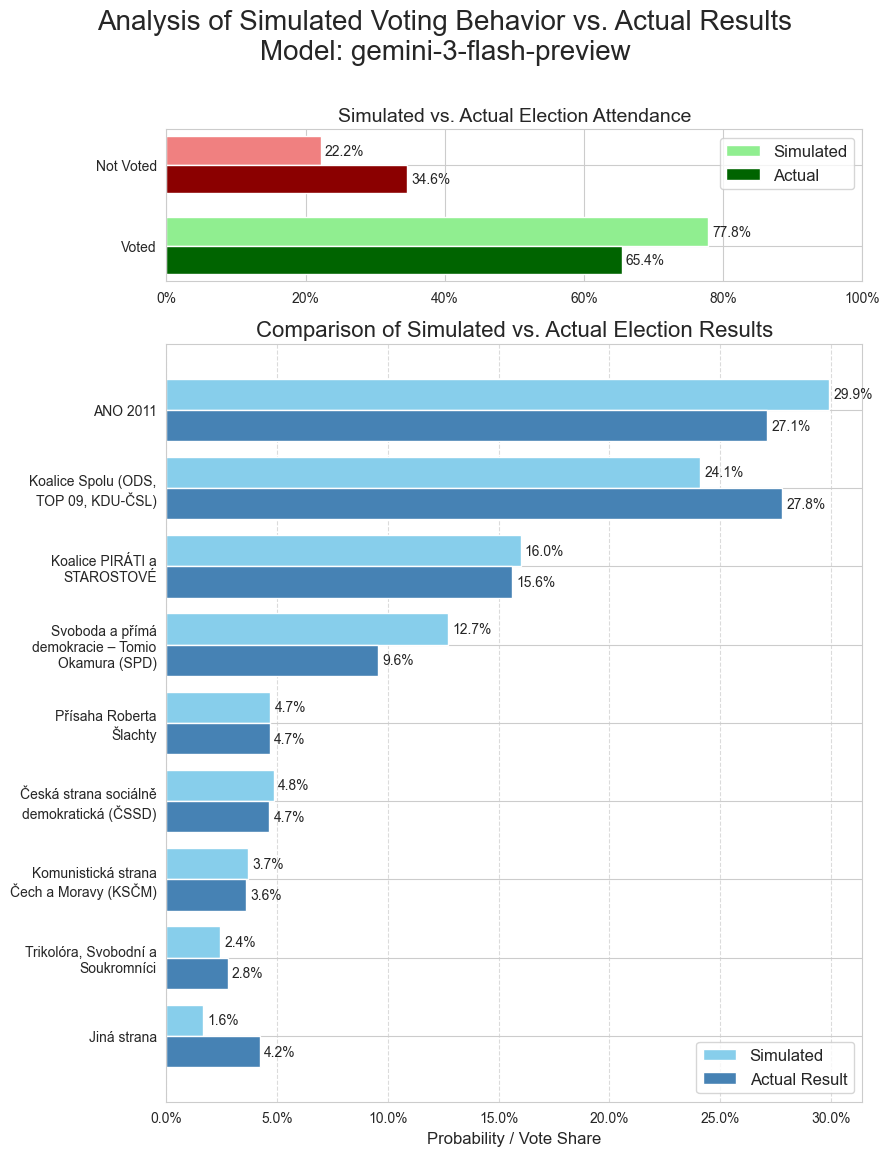

In [4]:
# Generate aggregated results and visualizations
predicted_results = data.aggregate_results_from_df(voting_results)
fig = visualization.visualize_comprehensive_results(
    predicted_results,
    actual_results_country,
    PARTY_COLUMNS,
    model_name=MODEL, actual_is_claimed=False
)

fig.savefig(f"graphs/{MODEL}_{VOTING_RESULT.__name__}.png")
print(f"Saved graph for {MODEL} and {VOTING_RESULT.__name__}")

In [5]:
row_sums = party_results_df.sum(axis=1)
df_skipped = party_results_df[row_sums != 0].copy()
party_results_df_norm_filtered = df_skipped.div(df_skipped.sum(axis=1), axis=0)

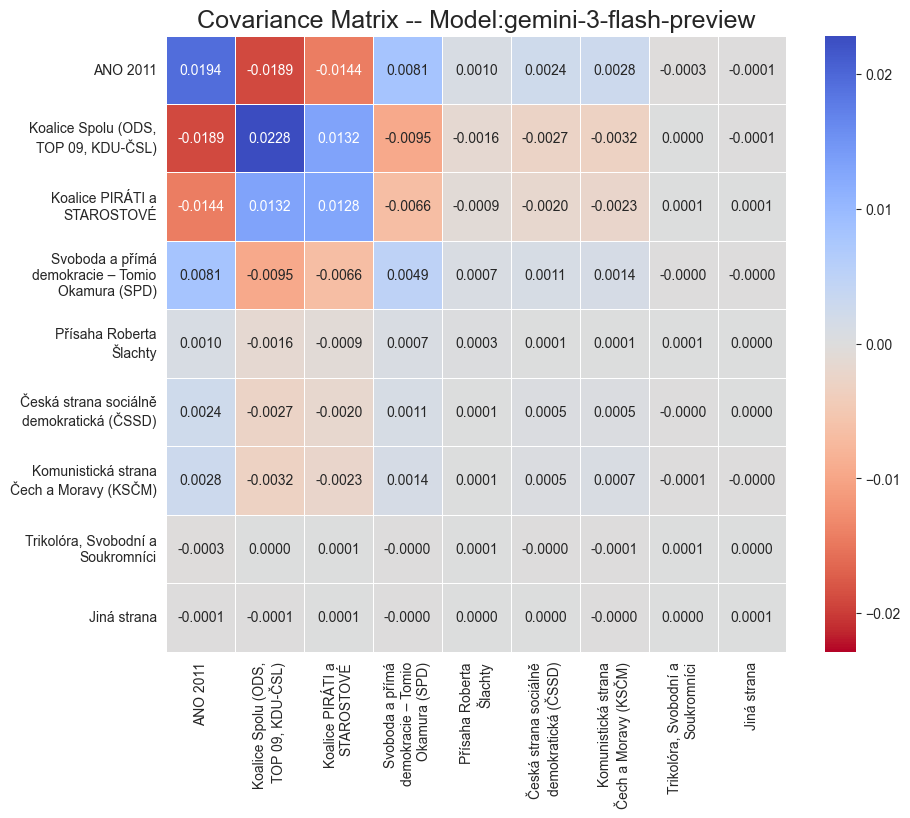

Saved covariance matrix and graph for gemini-3-flash-preview and VotingProbabilities


In [6]:
cov_matrix = party_results_df_norm_filtered[PARTY_COLUMNS].cov()
max = cov_matrix.abs().max().max()
fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cov_matrix,
    annot=True,       # CRITICAL: Show the numbers in the cells
    cmap='coolwarm_r',  # A diverging colormap is best to see pos/neg values
    fmt=".4f",        # Format to two decimal places
    linewidths=.5,
    vmin=-max, vmax=max
)
# You can adjust the width parameter to control wrapping
y_labels = [item.get_text() for item in ax.get_yticklabels()]
wrapped_y_labels = [textwrap.fill(label, width=21) for label in y_labels]
ax.set_yticklabels(wrapped_y_labels, rotation=0, horizontalalignment='right', verticalalignment='center')
ax.set_xticklabels(wrapped_y_labels, rotation=90, horizontalalignment='right', verticalalignment='center', rotation_mode='anchor')

plt.title(f'Covariance Matrix -- Model:{MODEL}', fontsize=18)
plt.show()

cov_matrix.to_csv(f"results/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.csv")
fig.savefig(f"graphs/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.png", bbox_inches='tight')
print(f"Saved covariance matrix and graph for {MODEL} and {VOTING_RESULT.__name__}")

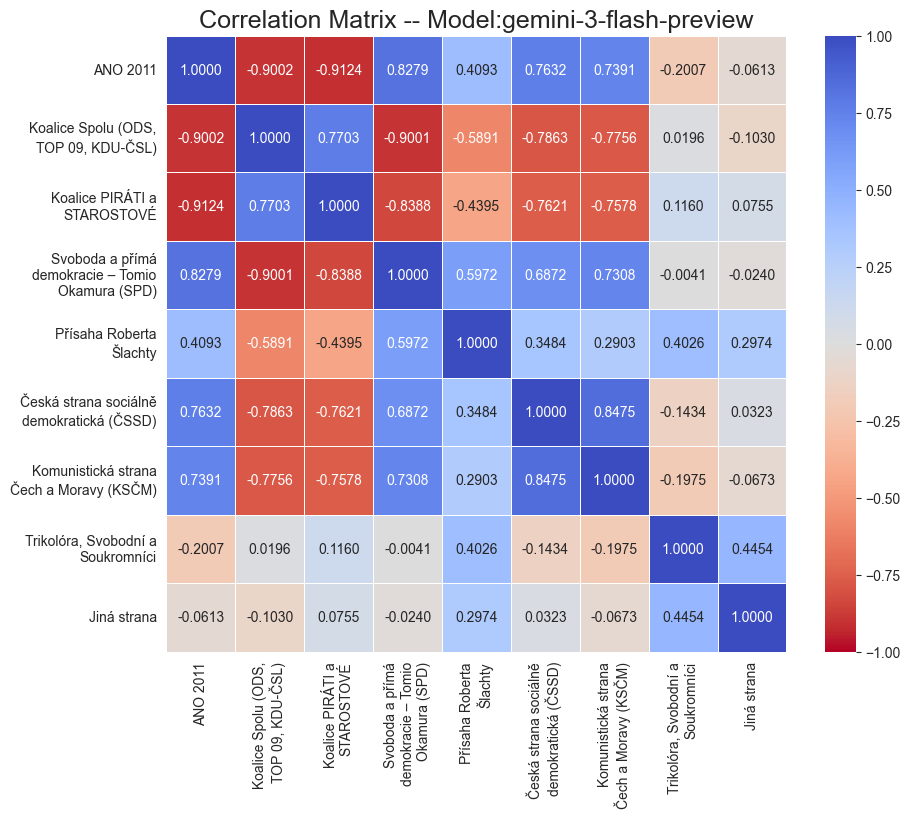

Saved correlation matrix and graph for gemini-3-flash-preview and VotingProbabilities


In [7]:
# cov_matrix = pd.read_csv(f"results/cov_matrix_{MODEL}_{VOTING_RESULT.__name__}.csv",index_col=0)

std_devs = np.sqrt(np.diag(cov_matrix))
outer_std = np.outer(std_devs, std_devs)
corr_matrix = cov_matrix / outer_std
np.fill_diagonal(corr_matrix.values, 1.0)

fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr_matrix,
    annot=True,       # CRITICAL: Show the numbers in the cells
    cmap='coolwarm_r',  # A diverging colormap is best to see pos/neg values
    fmt=".4f",        # Format to two decimal places
    linewidths=.5,
    vmin=-1.0, vmax=1.0
)
# You can adjust the width parameter to control wrapping
y_labels = [item.get_text() for item in ax.get_yticklabels()]
wrapped_y_labels = [textwrap.fill(label, width=21) for label in y_labels]
ax.set_yticklabels(wrapped_y_labels, rotation=0, horizontalalignment='right', verticalalignment='center')
ax.set_xticklabels(wrapped_y_labels, rotation=90, horizontalalignment='right', verticalalignment='center', rotation_mode='anchor')

plt.title(f'Correlation Matrix -- Model:{MODEL}', fontsize=18)
plt.show()

cov_matrix.to_csv(f"results/corr_matrix_{MODEL}_{VOTING_RESULT.__name__}.csv")
fig.savefig(f"graphs/corr_matrix_{MODEL}_{VOTING_RESULT.__name__}.png", bbox_inches='tight')
print(f"Saved correlation matrix and graph for {MODEL} and {VOTING_RESULT.__name__}")

## Region Analysis

In [8]:
region_indices = claimed_results_df.groupby('region', observed=True).groups

Saved regional MAE CSV to: results/regional_pairwise_mae_t=0_gemini-3-flash-preview.csv


,region,Predicted vs Actual,Predicted vs Claimed,Actual vs Claimed
0,Česko,0.015,0.024,0.014
1,Hlavní město Praha,0.011,0.022,0.023
2,Středočeský kraj,0.020,0.033,0.023
3,Jihočeský kraj,0.024,0.038,0.018
4,Plzeňský kraj,0.015,0.028,0.027
5,Karlovarský kraj,0.030,0.059,0.040
6,Ústecký kraj,0.033,0.027,0.013
7,Liberecký kraj,0.034,0.043,0.021
8,Královéhradecký kraj,0.017,0.054,0.038
9,Pardubický kraj,0.027,0.050,0.033


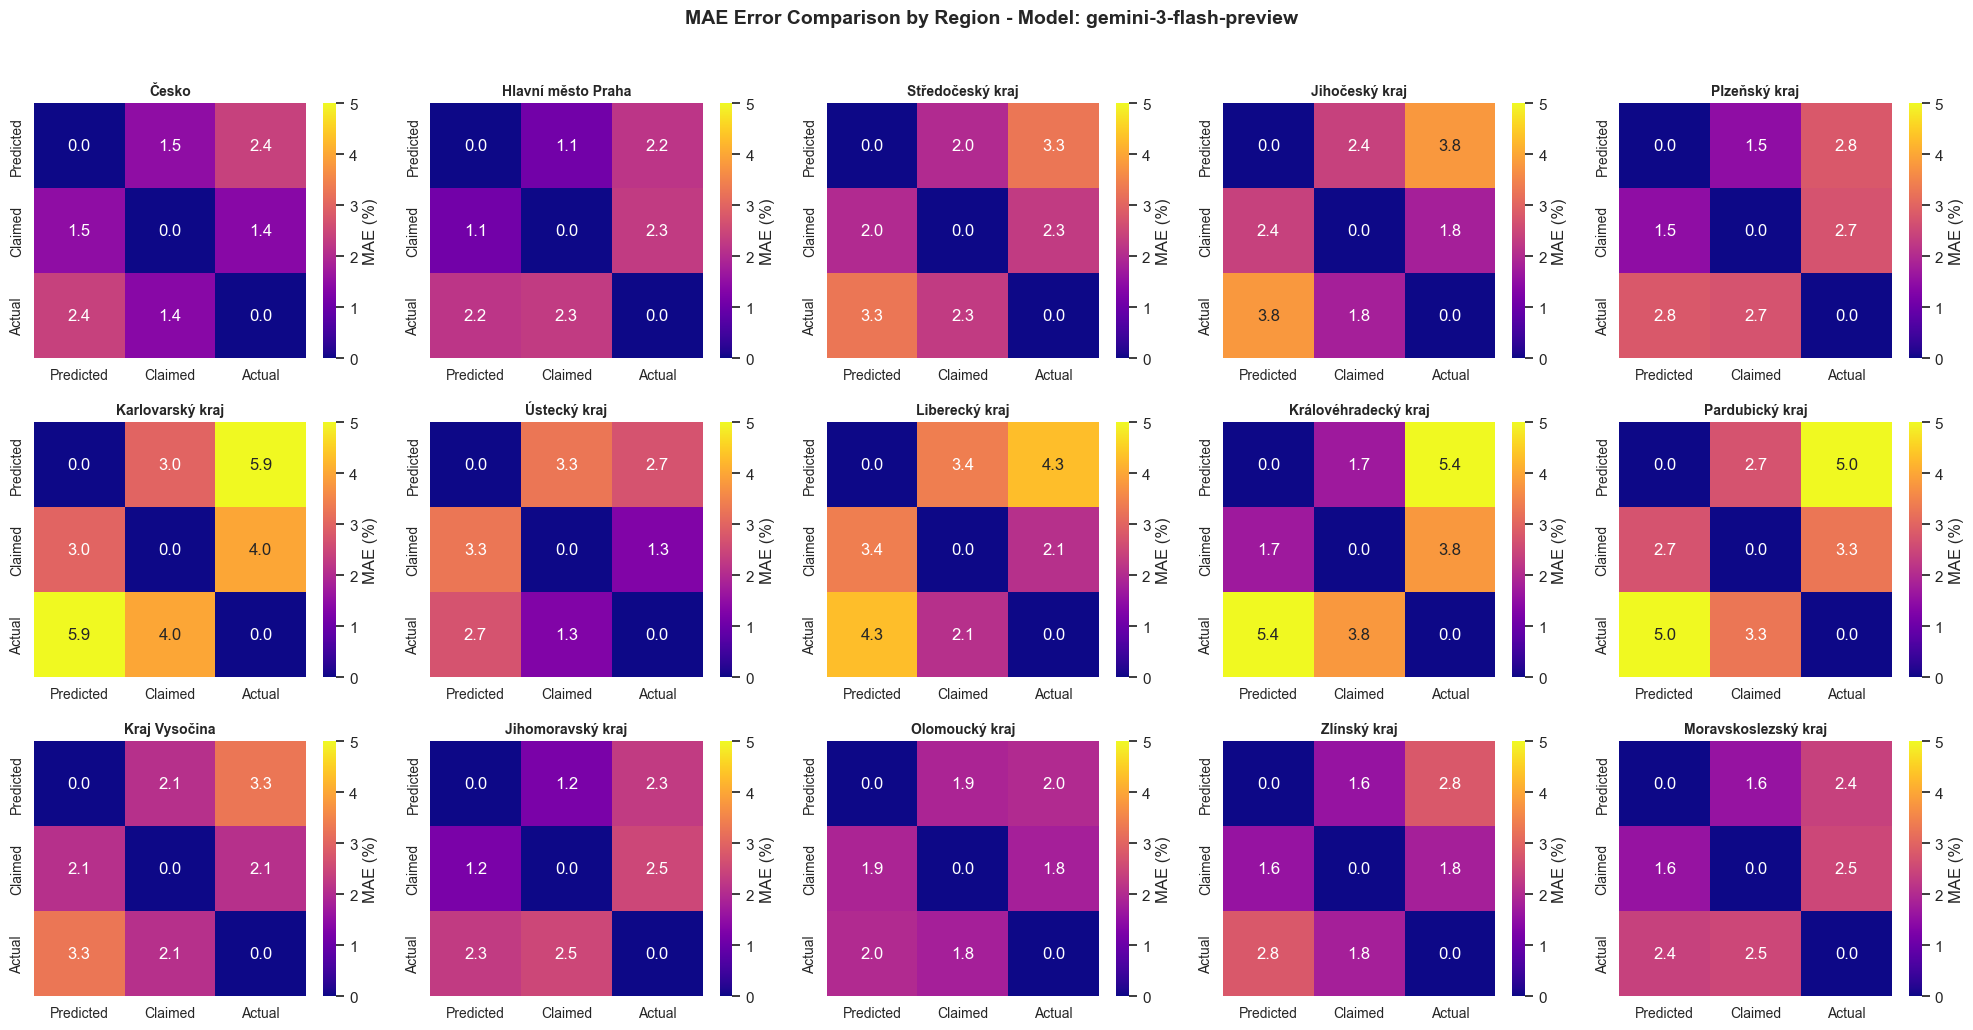

In [9]:
rows = []

for idx, actual_results_region in actual_results_df.iterrows():
    region = actual_results_region["region"]
    if region == constants.COUNTRY:
        claimed_votes_region = claimed_results_df
        predicted_votes_region = voting_results
    else:
        claimed_votes_region = claimed_results_df.iloc[region_indices[region]]
        predicted_votes_region = voting_results.iloc[region_indices[region]]

    claimed_results_region = GET_RESULTS(claimed_votes_region)
    predicted_results_region = data.aggregate_results_from_df(predicted_votes_region)

    actual_results_region = actual_results_region[PARTY_COLUMNS]
    predicted_results_region = predicted_results_region[PARTY_COLUMNS]
    claimed_results_region = claimed_results_region[PARTY_COLUMNS]

    mae_pred_vs_clmd = mean_absolute_error(predicted_results_region, claimed_results_region)
    mae_pred_vs_actu = mean_absolute_error(predicted_results_region, actual_results_region)
    mae_actu_vs_clmd = mean_absolute_error(actual_results_region, claimed_results_region)

    rows.append({
        "region": region,
        "Predicted vs Actual": round(mae_pred_vs_actu, 3),
        "Predicted vs Claimed": round(mae_pred_vs_clmd, 3),
        "Actual vs Claimed": round(mae_actu_vs_clmd, 3),
    })

regional_mae_df = pd.DataFrame(rows, columns=[
    "region",
    "Predicted vs Actual",
    "Predicted vs Claimed",
    "Actual vs Claimed",
])

# Ensure results directory exists
os.makedirs("results", exist_ok=True)
# Construct filename with model and temperature for traceability
csv_path = f"results/regional_pairwise_mae_t={TEMPERATURE}_{MODEL}.csv"
regional_mae_df.to_csv(csv_path, index=False)
print(f"Saved regional MAE CSV to: {csv_path}")

fig = visualization.visualize_region_errors(regional_mae_df, title=f"MAE Error Comparison by Region - Model: {MODEL}",ncols=5)
fig.savefig(f"graphs/regional_mae_{MODEL}.png")
regional_mae_df

## Result Distribution

In [11]:
party_results_df_tmp = party_results_df
# party_results_df_tmp = generate_prob_vectors_df(4000, 9)

Calculated Mean Vector (Average Voter Profile):
[0.31  0.226 0.152 0.133 0.048 0.05  0.039 0.024 0.017]


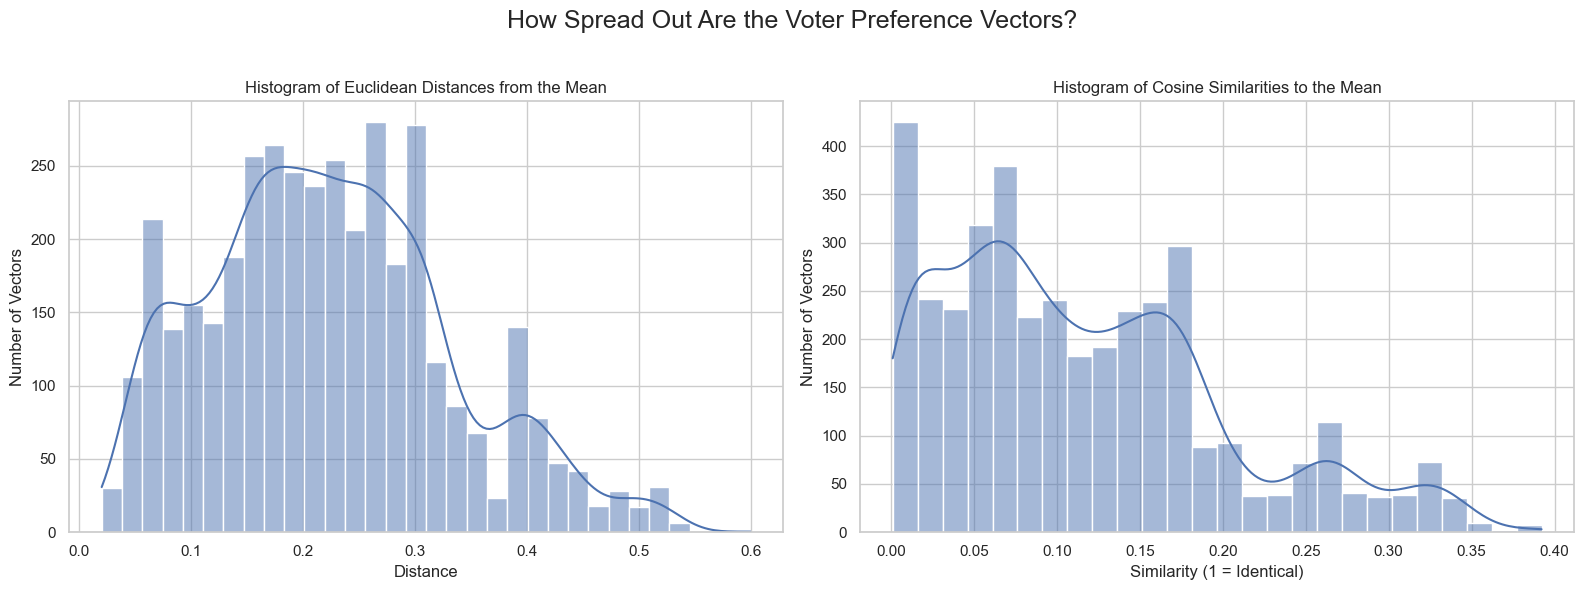

In [12]:
# --- Calculate the Mean Vector (The "Center of the Cloud") ---
mean_vector = party_results_df_tmp.mean().values
print("Calculated Mean Vector (Average Voter Profile):")
print(np.round(mean_vector, 3))

# --- Calculate Distances from Each Vector to the Mean ---
# We need to reshape the mean_vector for the distance functions
mean_vector_reshaped = mean_vector.reshape(1, -1)
euclidean_dists = euclidean_distances(party_results_df_tmp.values, mean_vector_reshaped).flatten()
cosine_sims = cosine_similarity(party_results_df_tmp.values, mean_vector_reshaped).flatten()

# --- Visualize the Spread with Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('How Spread Out Are the Voter Preference Vectors?', fontsize=18)

# Plot Euclidean Distance Histogram
sns.histplot(euclidean_dists, ax=axes[0], kde=True)
axes[0].set_title('Histogram of Euclidean Distances from the Mean')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Number of Vectors')

# Plot Cosine Similarity Histogram
sns.histplot(1-cosine_sims, ax=axes[1], kde=True)
axes[1].set_title('Histogram of Cosine Similarities to the Mean')
axes[1].set_xlabel('Similarity (1 = Identical)')
axes[1].set_ylabel('Number of Vectors')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

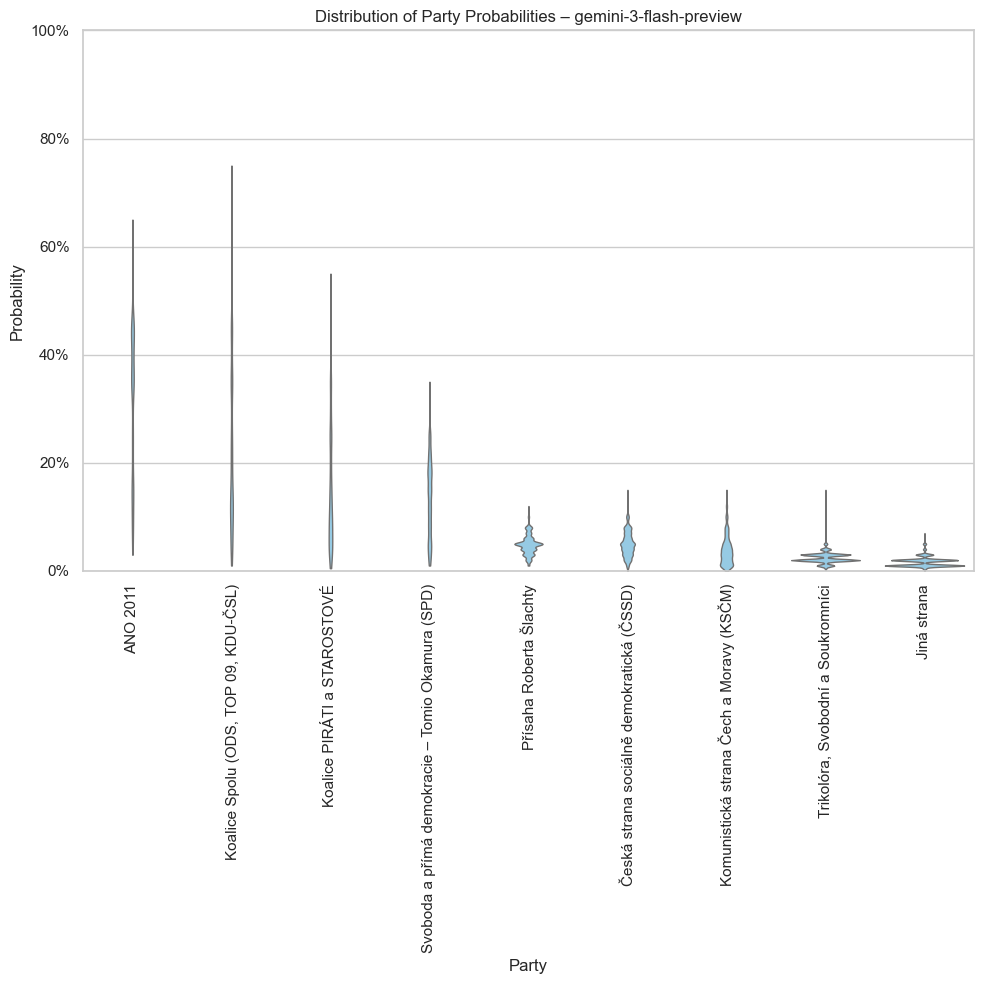

In [13]:
fig = visualization.visualize_party_probability_distribution(
    party_results_df_tmp,
    PARTY_COLUMNS,
    title=f"Distribution of Party Probabilities – {MODEL}",
    kind="violin",
    add_points=False,
    point_size=2.0,
    alpha=0.25,
)
fig.savefig(f"graphs/party_probability_distribution_{MODEL}.png")
plt.show()

## Multi-Model Comparison

Compare results across different models.

In [15]:
# List of model names to compare
model_names = [
    "gpt-4.1-nano",
    "gpt-4o-mini",
    "gpt-4.1",
    "gpt-4o"
]

# Load all model results
voting_results_list = []
for model_name in model_names:
    try:
        voting_results_df = pd.read_csv(f"results/voting_results_n=3880_t={TEMPERATURE}_{model_name}_{VOTING_RESULT.__name__}.csv", index_col=0)
        voting_results_list.append(voting_results_df)
        print(f"✓ Loaded {model_name}: {len(voting_results_df)} respondents")
    except FileNotFoundError:
        print(f"✗ File not found for {model_name}")
        voting_results_list.append({})


✓ Loaded gpt-4.1-nano: 3880 respondents
✓ Loaded gpt-4o-mini: 3880 respondents
✓ Loaded gpt-4.1: 3880 respondents
✓ Loaded gpt-4o: 3880 respondents


Saved graph for gpt-4.1-nano
Saved graph for gpt-4o-mini
Saved graph for gpt-4.1
Saved graph for gpt-4o


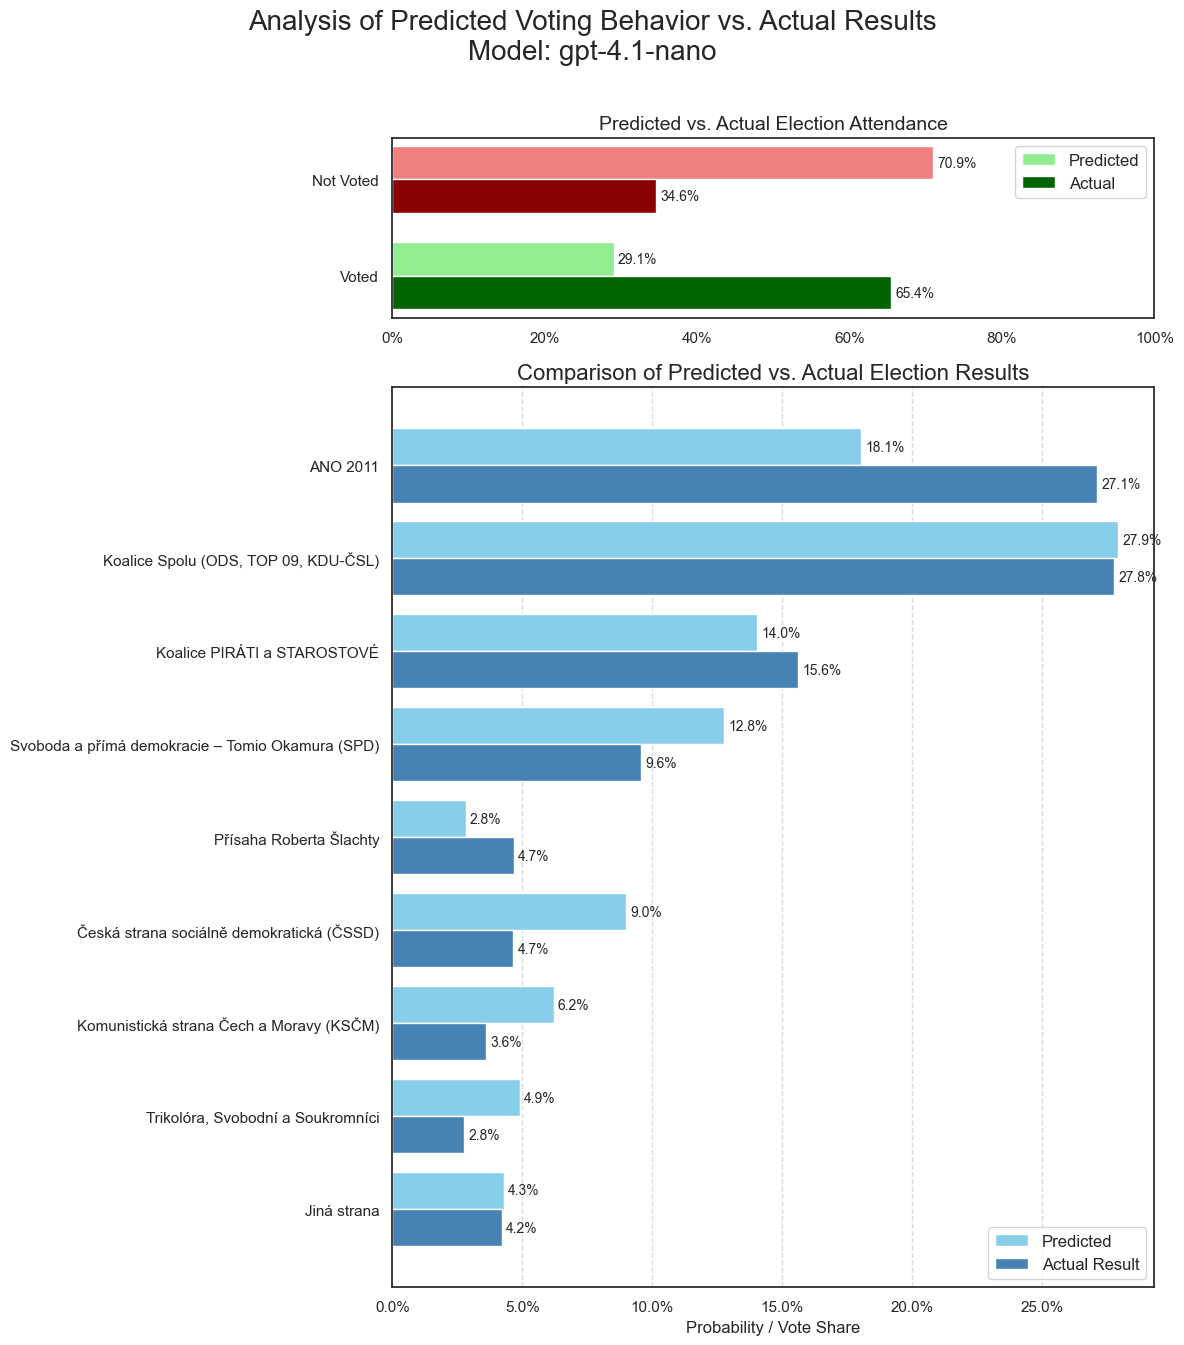

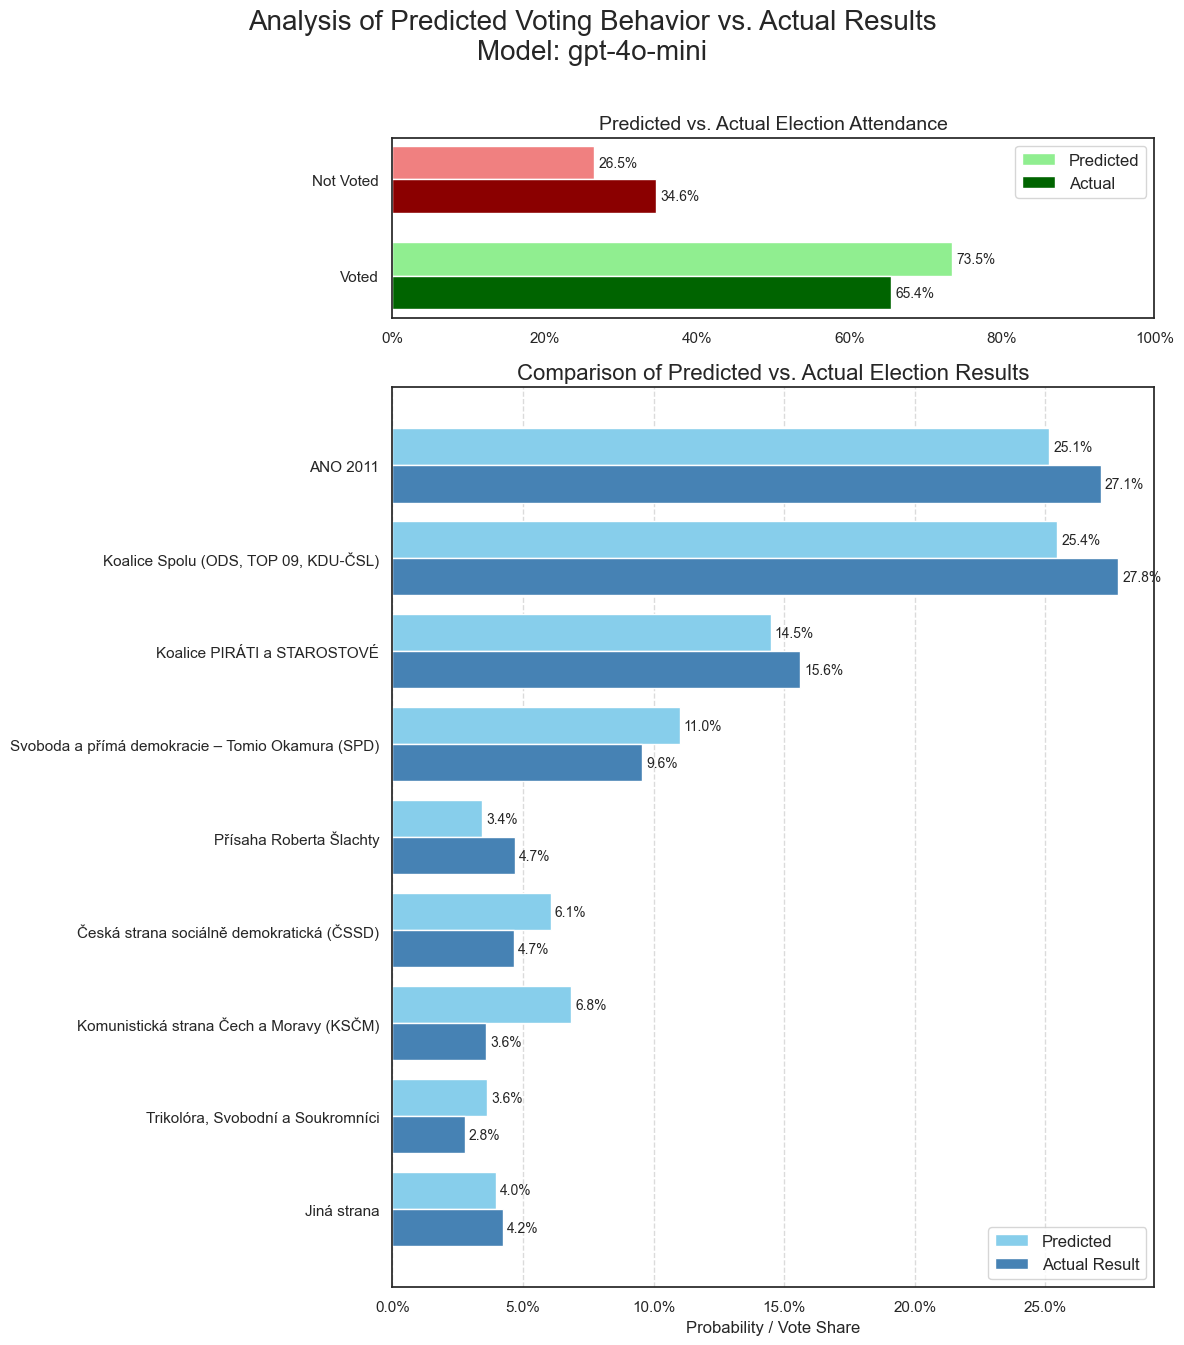

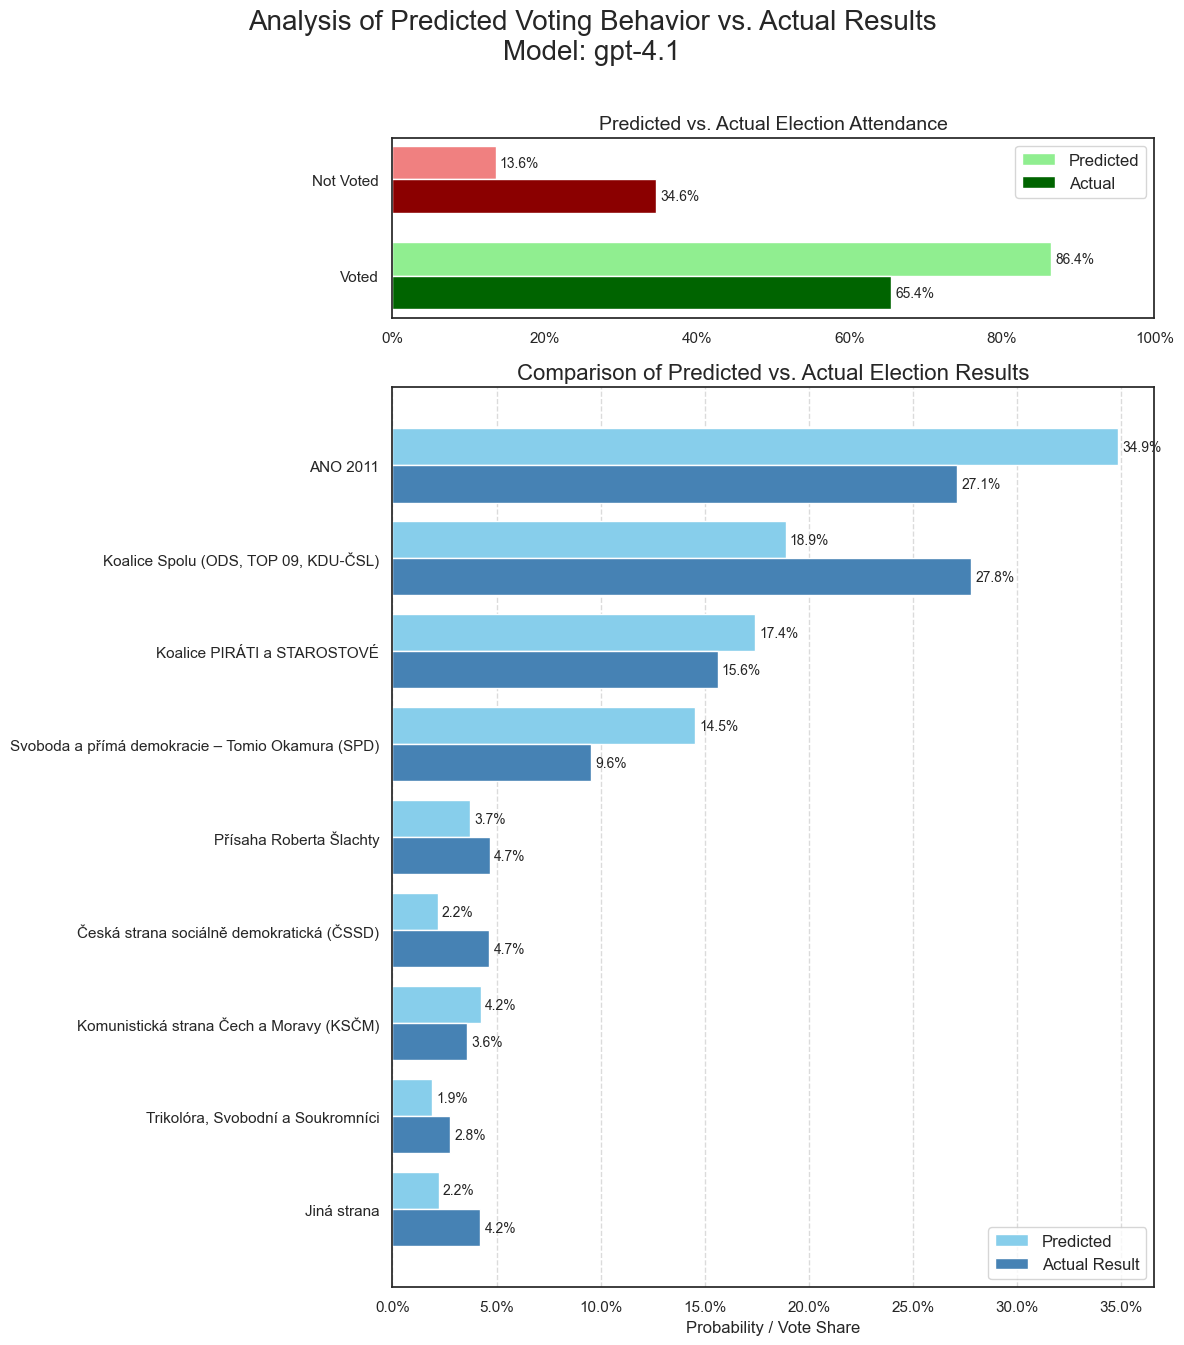

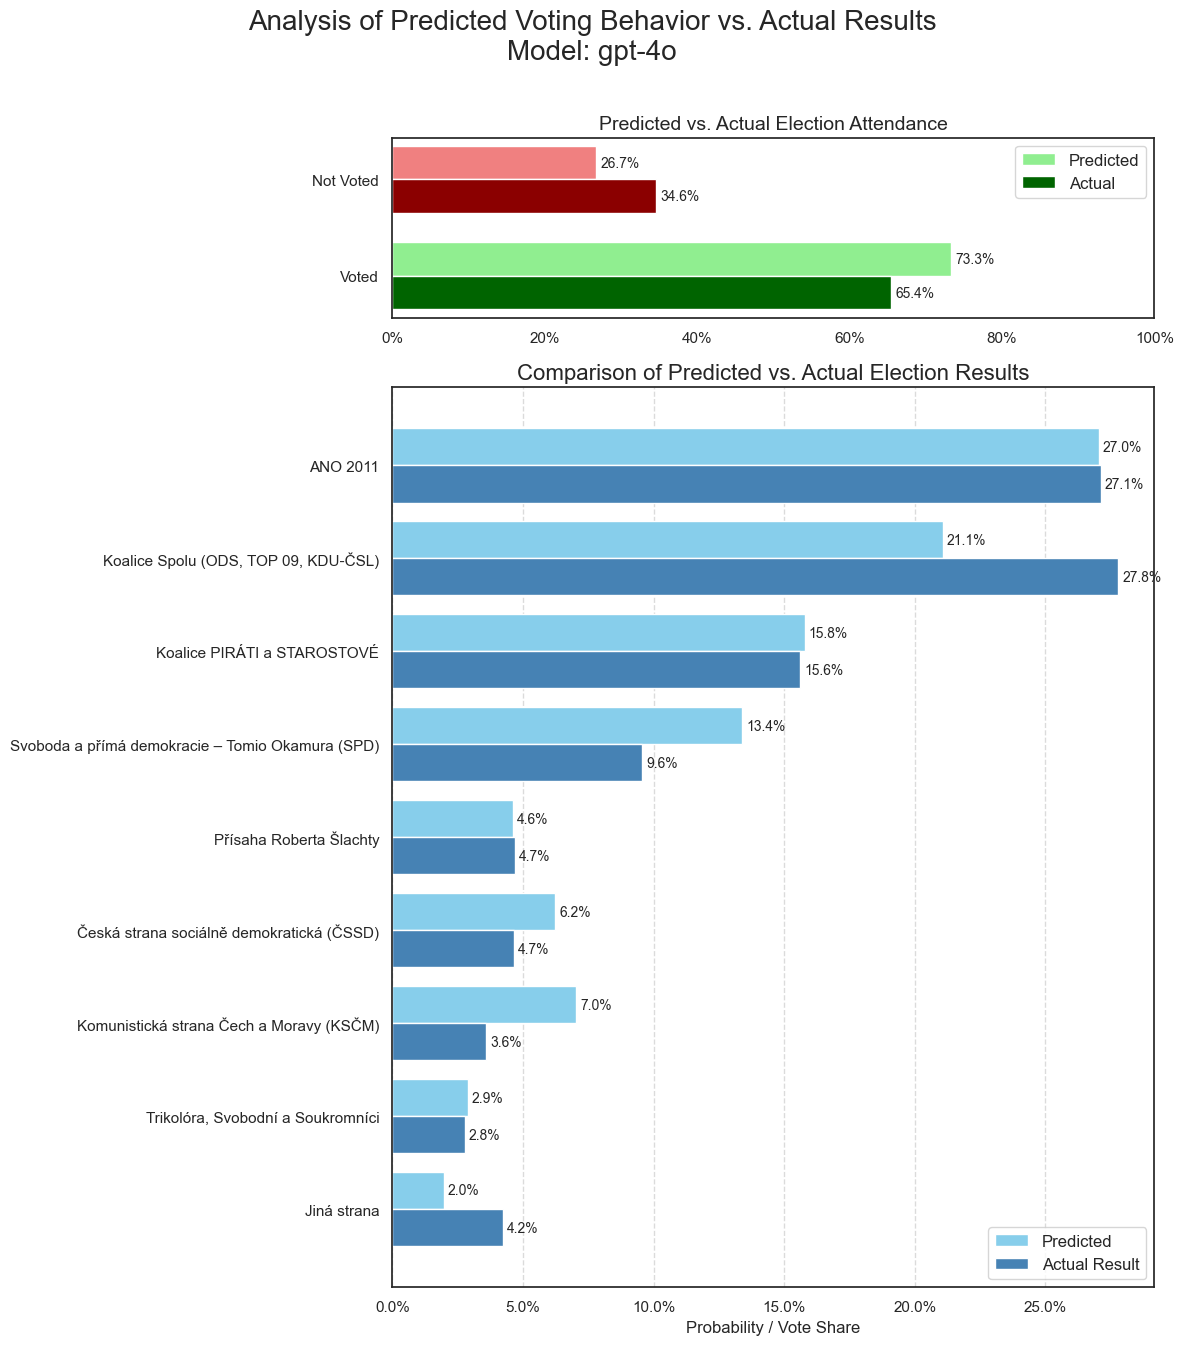

In [17]:
# Generate and save comparison graphs
for model_name, voting_results_df in zip(model_names, voting_results_list):

    predicted_results = data.aggregate_results_from_df(voting_results_df)
    fig = visualization.visualize_comprehensive_results(
        predicted_results,
        actual_results_country,
        PARTY_COLUMNS,
        model_name=model_name, actual_is_claimed=False
)
    # Save the plot as a PNG file
    if fig:
        fig.savefig(f"graphs/{model_name}.png")
        print(f"Saved graph for {model_name}")

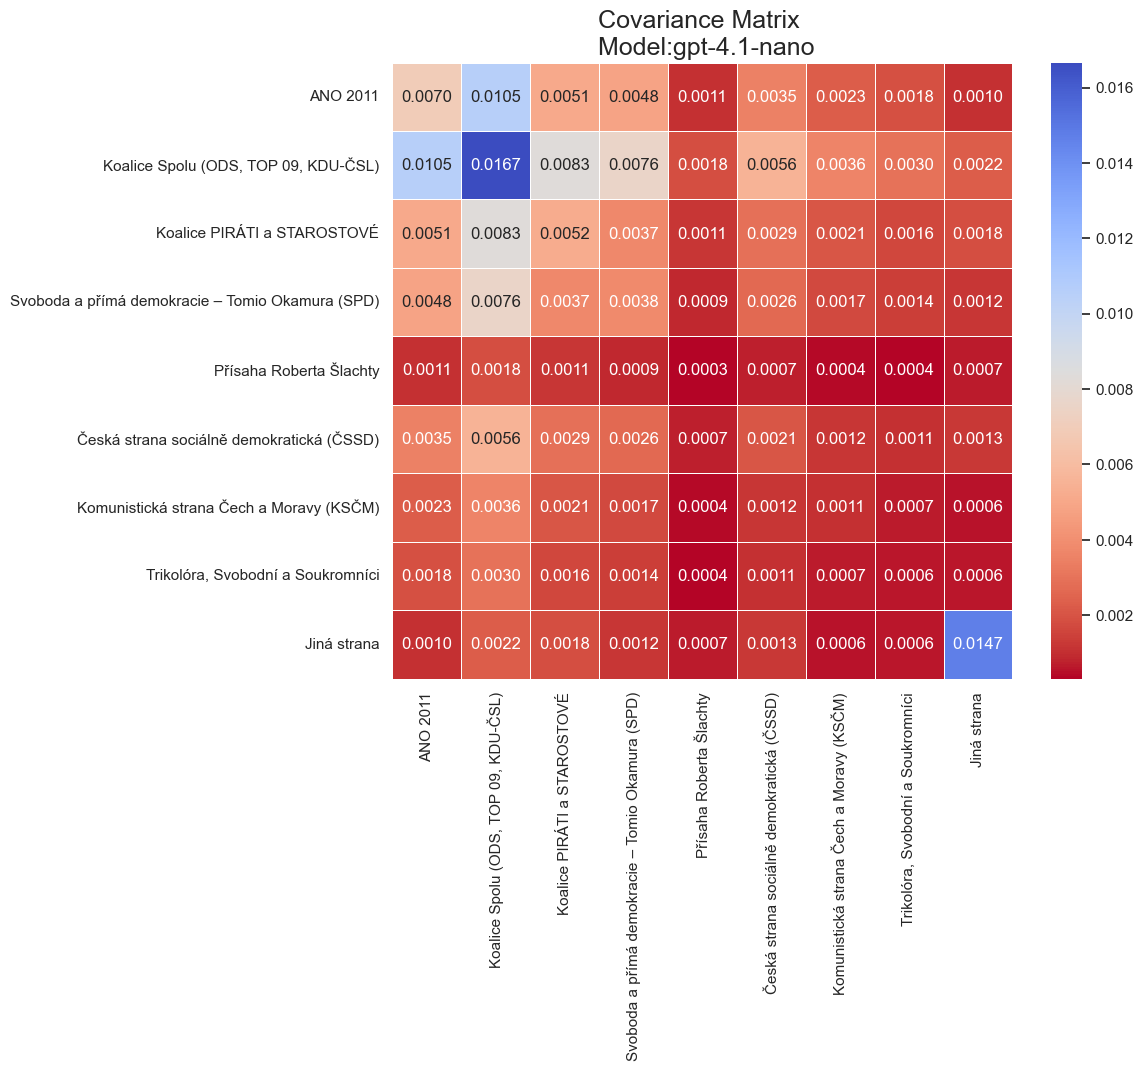

Saved covariance matrix and graph for gpt-4.1-nano


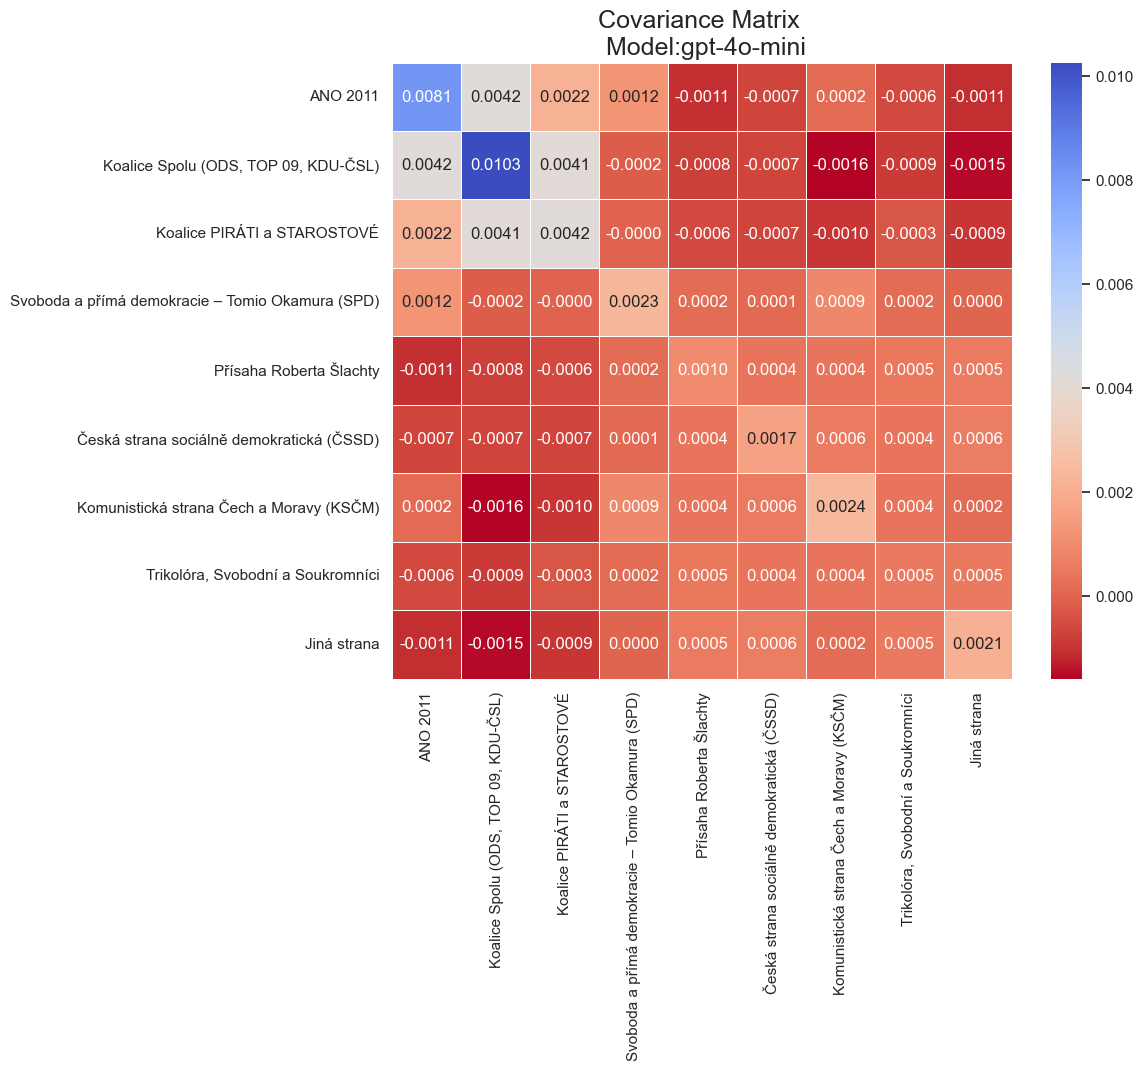

Saved covariance matrix and graph for gpt-4o-mini


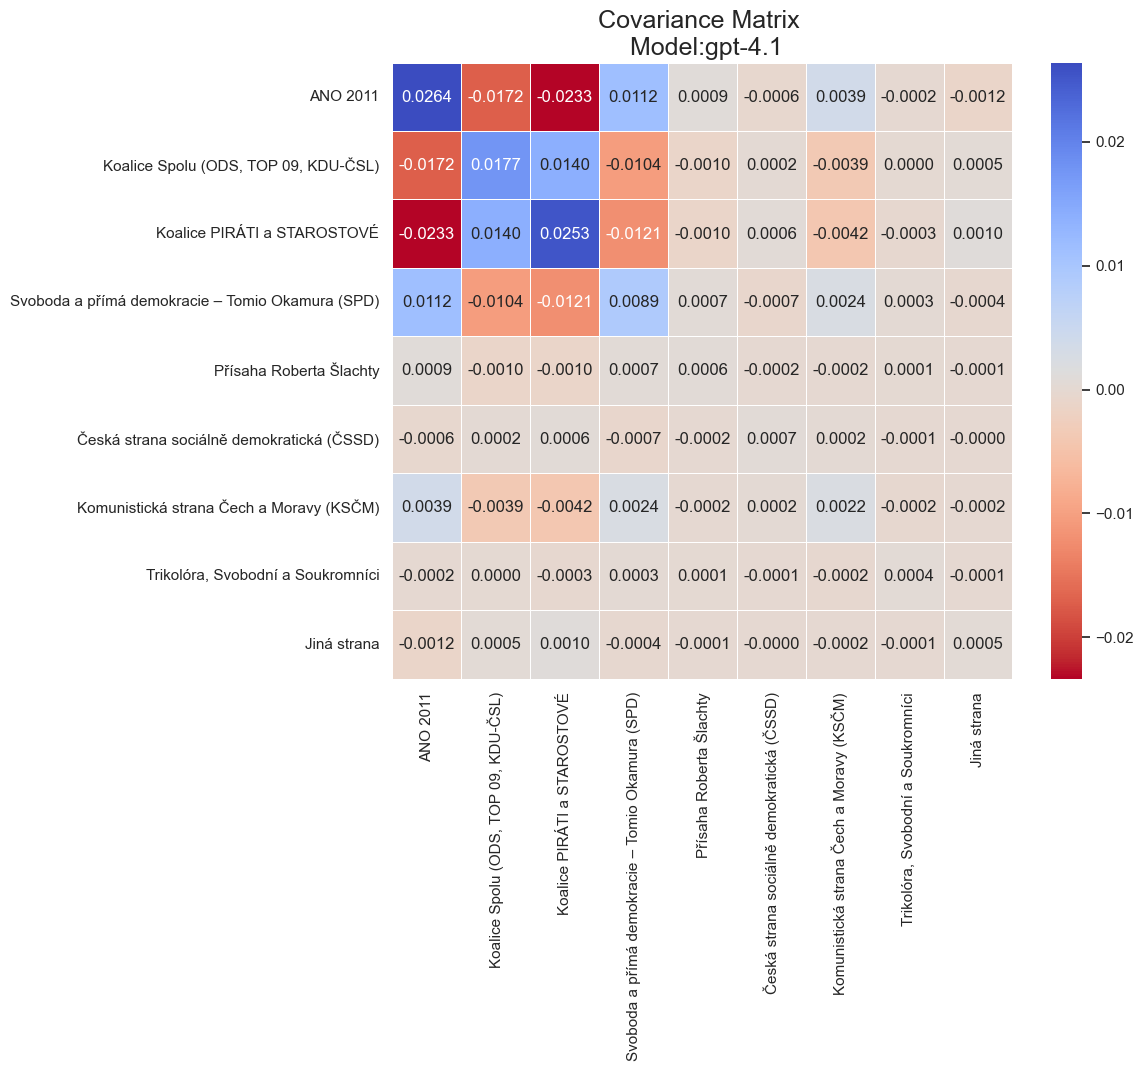

Saved covariance matrix and graph for gpt-4.1


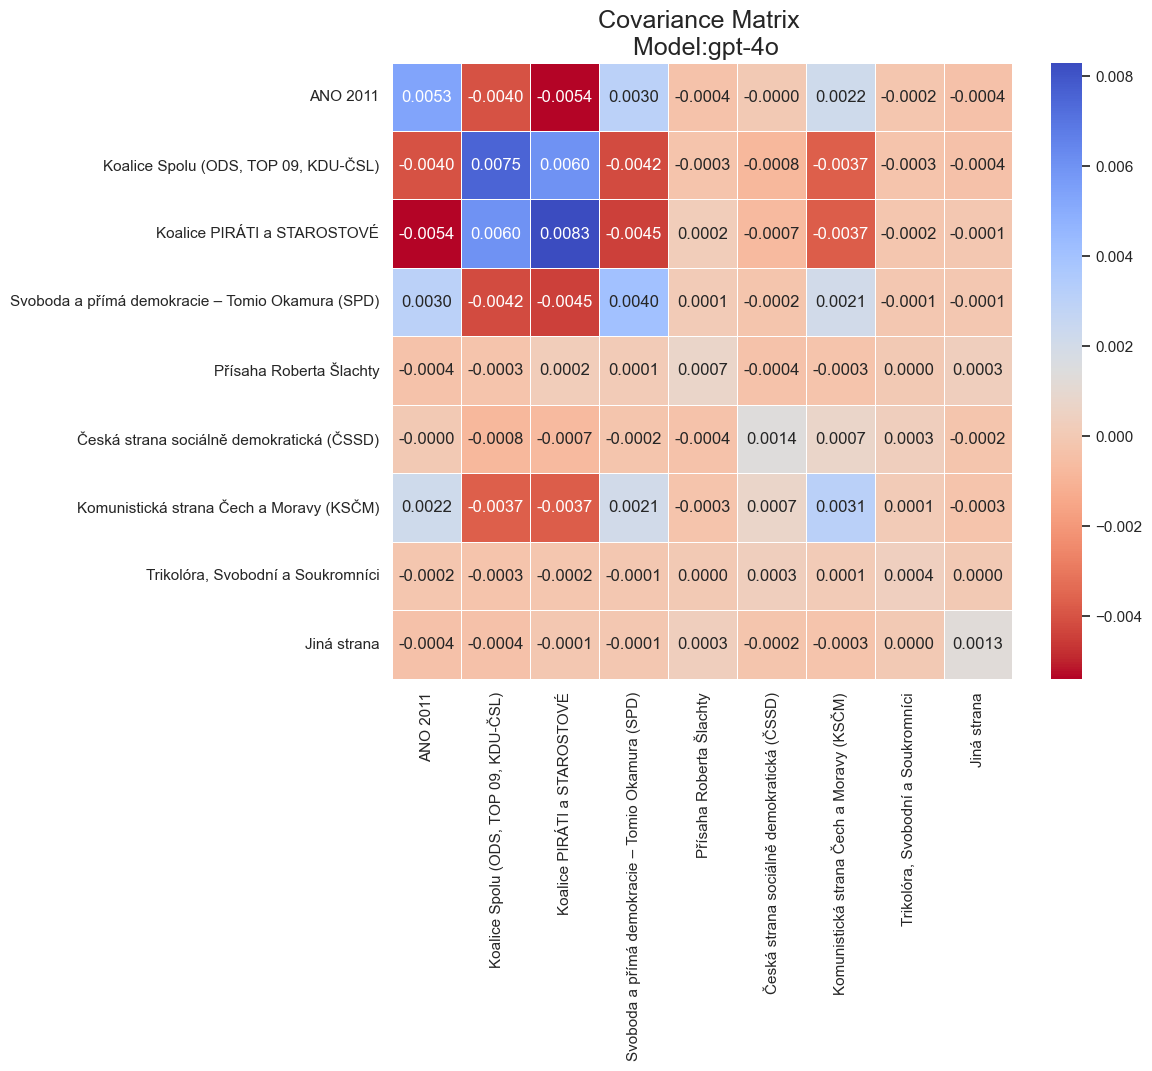

Saved covariance matrix and graph for gpt-4o


In [18]:
# Visualize the matrix with a heatmap
for model_name, voting_results_df in zip(model_names, voting_results_list):

    cov_matrix = voting_results_df[PARTY_COLUMNS].cov()
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(
        cov_matrix,
        annot=True,       # CRITICAL: Show the numbers in the cells
        cmap='coolwarm_r',  # A diverging colormap is best to see pos/neg values
        fmt=".4f",        # Format to two decimal places
        linewidths=.5
    )
    plt.title(f'Covariance Matrix \n Model:{model_name}', fontsize=18)
    plt.show()

    cov_matrix.to_csv(f"results/cov_matrix_{model_name}.csv")
    fig.savefig(f"graphs/cov_matrix_{model_name}.png")
    print(f"Saved covariance matrix and graph for {model_name}")

## Latent

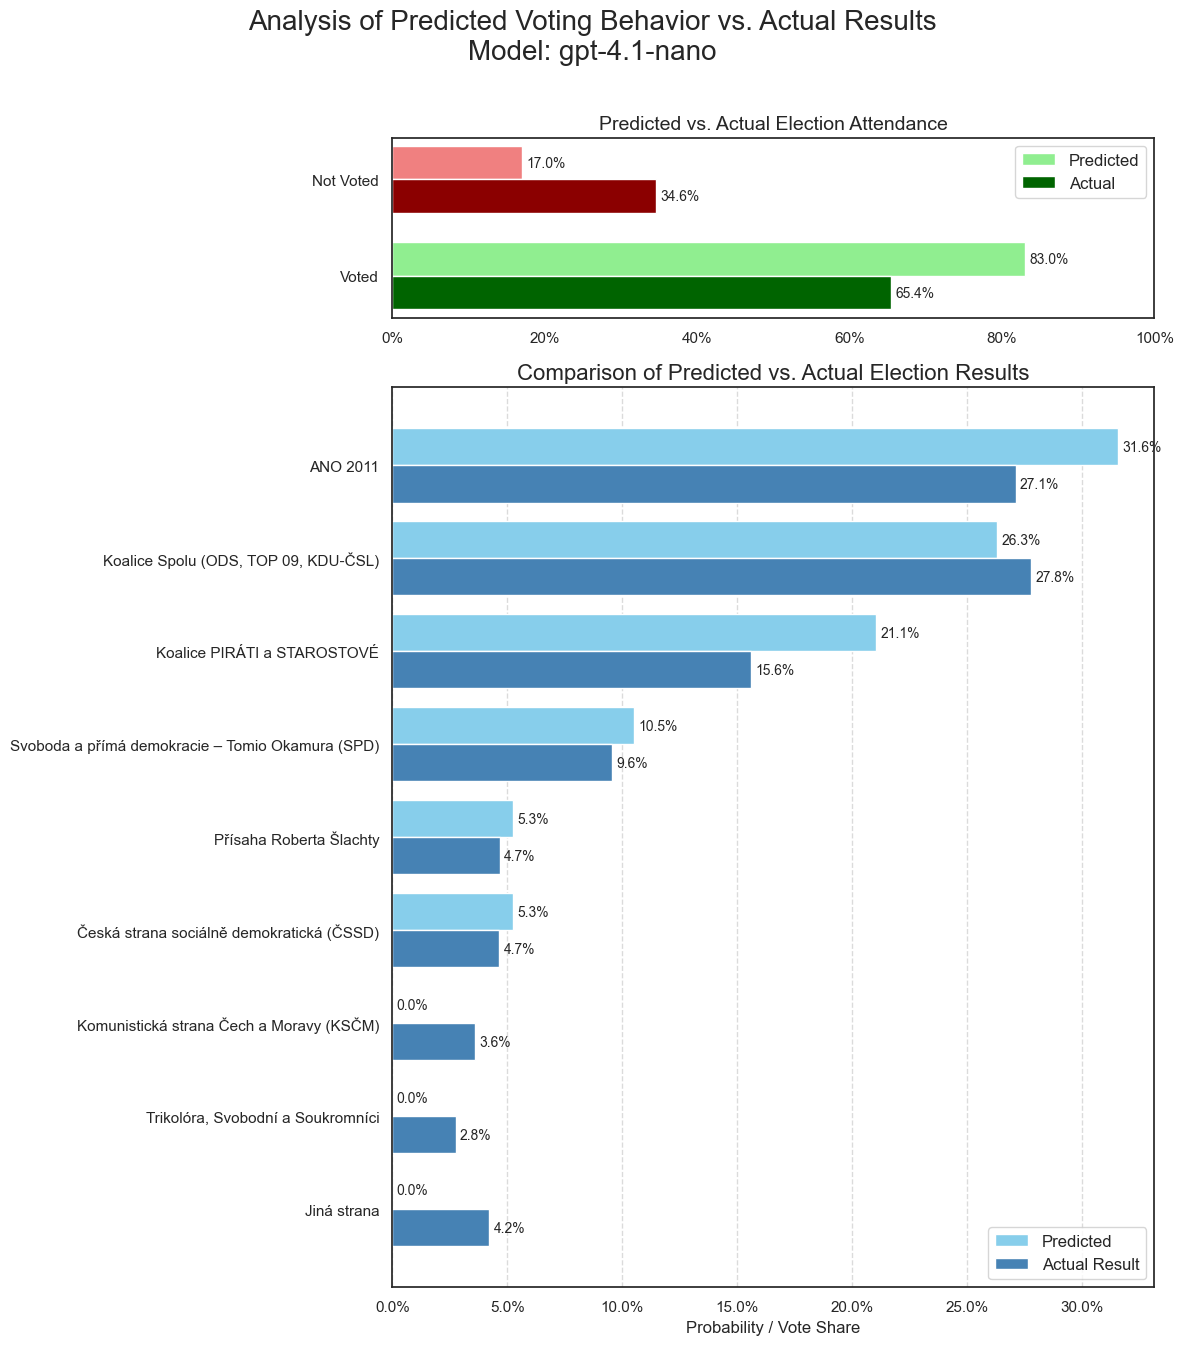

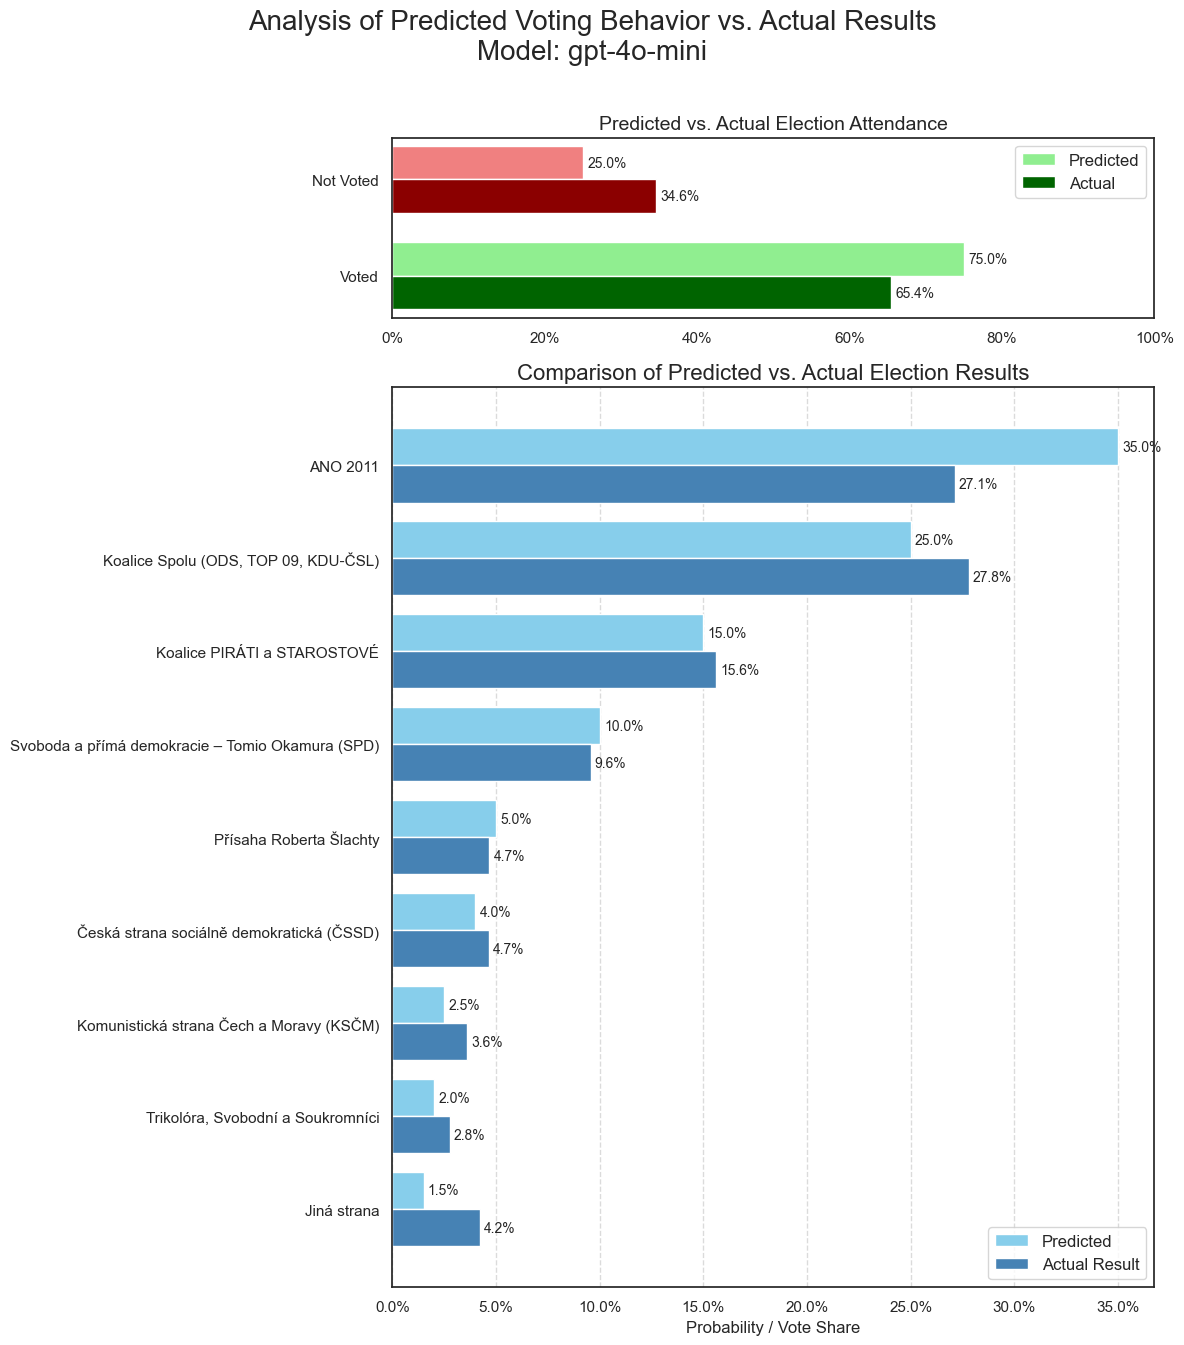

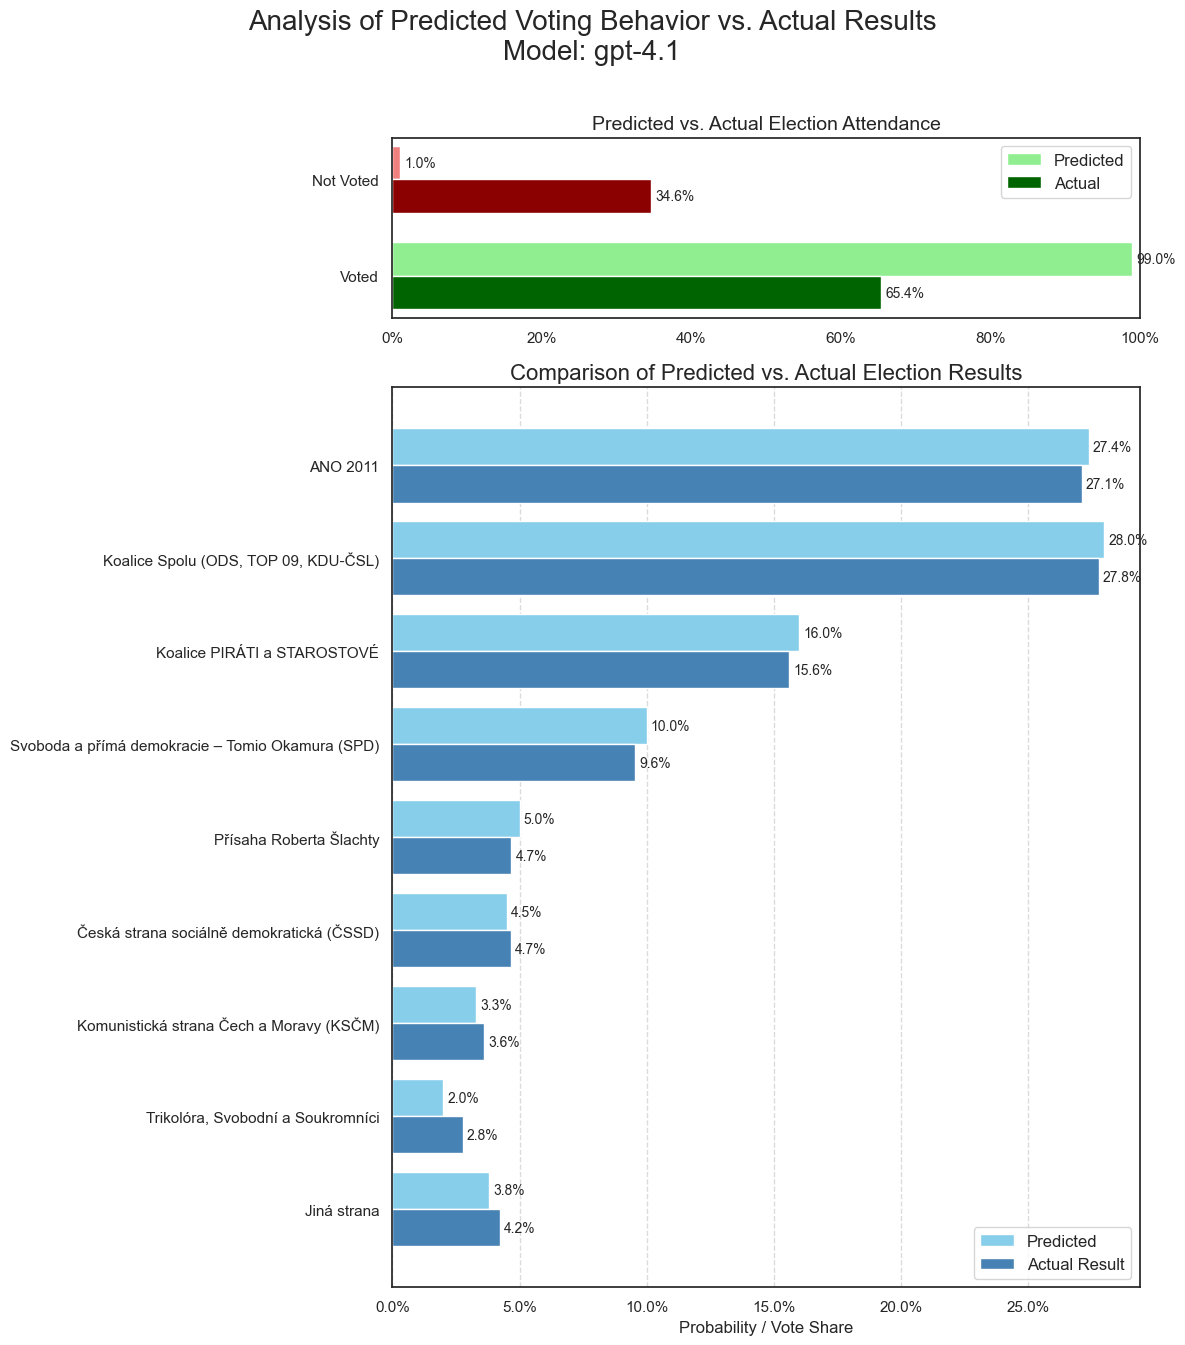

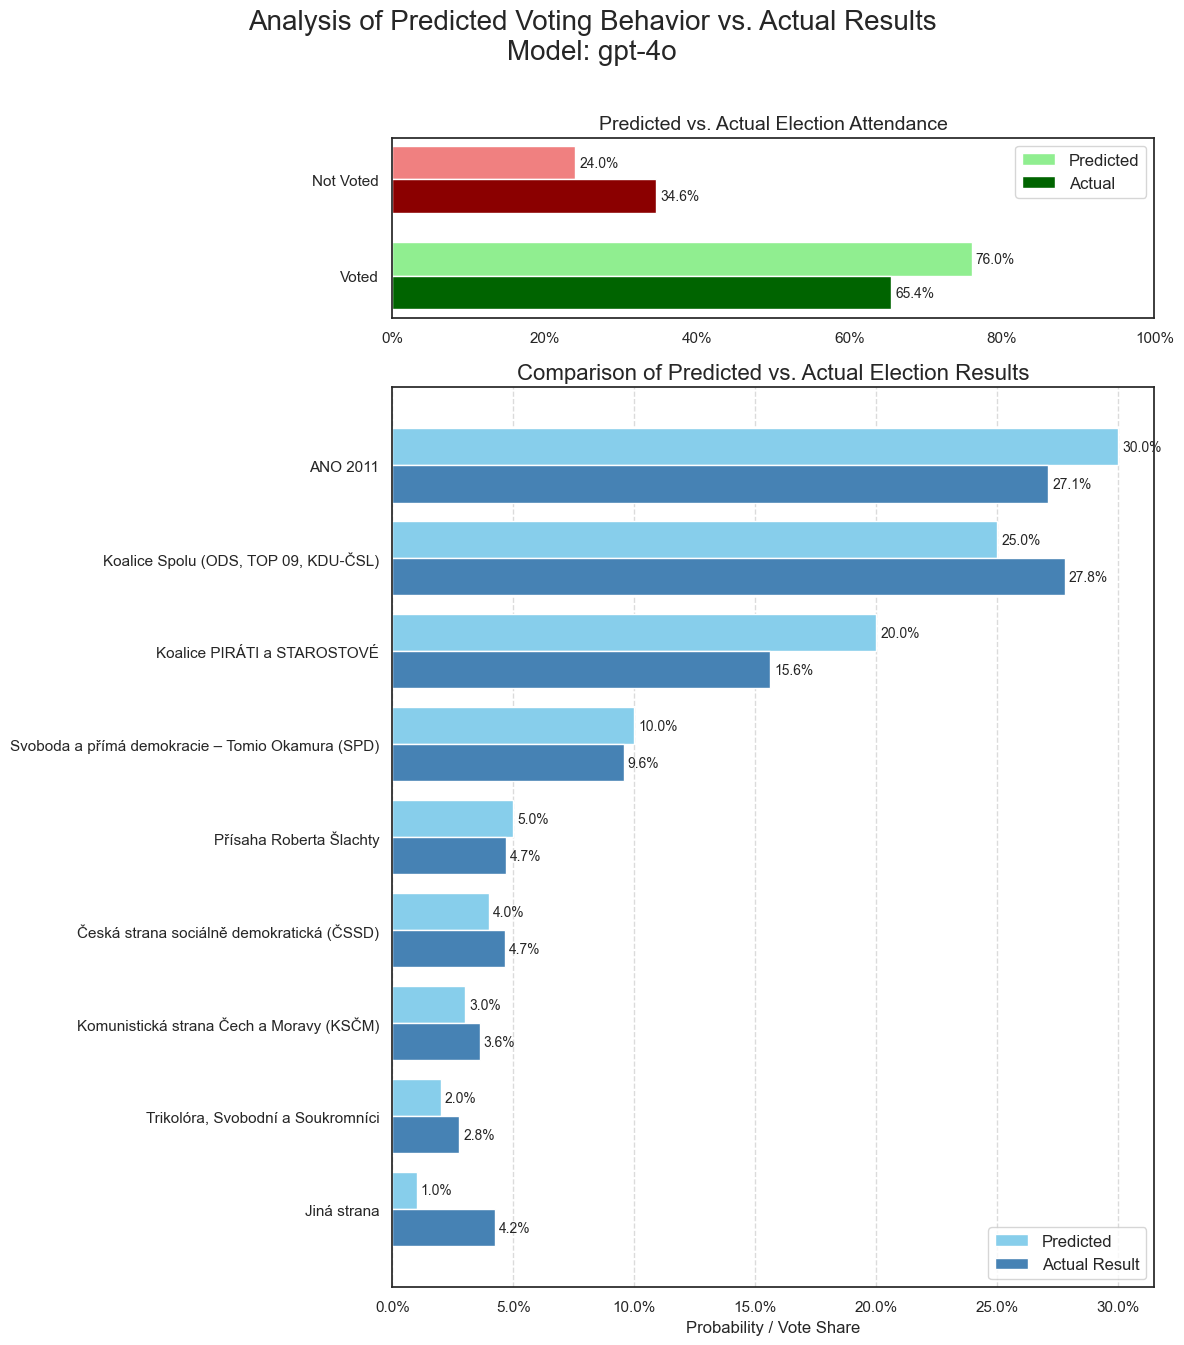

In [19]:
latent_results_df = pd.read_csv(f"results/LatentPreferences.csv")
for idx,result in latent_results_df.iterrows():
    model = result['model']
    fig = visualization.visualize_comprehensive_results(
        result,
        actual_results_country,
        PARTY_COLUMNS,
        model_name= model, actual_is_claimed=False
    )
    fig.savefig(f"graphs/latent_{model}.png")